In [1]:
import subprocess
import os

def launch_sglang_server(
    port=8100,
    model_path="qwen/qwen2.5-0.5b-instruct",
    tp_size=1,
    mem_fraction=0.04,
    context_length=8192,
    gpu_id=2,
    log_dir=None,
):
    env = os.environ.copy()
    env["CUDA_VISIBLE_DEVICES"] = str(gpu_id)

    cmd = [
        "python", "-m", "sglang.launch_server",
        "--model-path", model_path,
        "--port", str(port),
        "--tp-size", str(tp_size),
        "--mem-fraction-static", str(mem_fraction),
        "--context-length", str(context_length),
        "--enable-metrics",
    ]

    if log_dir:
        os.makedirs(log_dir, exist_ok=True)
        log_file = open(f"{log_dir}/server_{port}.log", "w")
        return subprocess.Popen(cmd, env=env, stdout=log_file, stderr=log_file)
    else:
        return subprocess.Popen(cmd, env=env)
    
    

In [2]:
# lunching sglang server

from sglang.utils import wait_for_server, print_highlight, terminate_process
port = 8100

import requests

port = 8100
server_process = launch_sglang_server(
    port=port,
    log_dir="None",  # important: keep logs
)

wait_for_server(f"http://127.0.0.1:{port}", process=server_process)

print("poll after startup:", server_process.poll())  # should be None

# url = f"http://127.0.0.1:{port}/v1/chat/completions"
# data = {
#     "model": "qwen/qwen2.5-0.5b-instruct",
#     "messages": [{"role": "user", "content": "What is the capital of France?"}],
# }

# response = requests.post(url, json=data, timeout=60)
# print(response.status_code)
# print(response.json())




        NOTE: Typically, the server runs in a separate terminal.
        In this notebook, we run the server and notebook code together, so their outputs are combined.
        To improve clarity, the server logs are displayed in the original black color, while the notebook outputs are highlighted in blue.
        To reduce the log length, we set the log level to warning for the server, the default log level is info.
        We are running those notebooks in a CI environment, so the throughput is not representative of the actual performance.
        
poll after startup: None


In [3]:
# checking if sglang is still alive

server_process.poll()

In [3]:
# sending a request to the sglang server and getting response

import requests
from transformers import AutoTokenizer

url = f"http://localhost:{port}/generate"

model_name = "Qwen/Qwen2.5-0.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

text = "hello"
token_ids = tokenizer.encode(text, add_special_tokens=False)
print(len(token_ids))

data = {
    "model": "qwen/qwen2.5-0.5b-instruct",
    "text": text, 
    # "text": "What does the fox say", 

    "sampling_params": {
            "temperature": 0,
            "max_new_tokens": 1,
        },
}

response = requests.post(url, json=data)
print_highlight(response.json())

print(response.json()["meta_info"]["prompt_tokens"], response.json()["meta_info"]["cached_tokens"], response.json()["text"])


/home/ssn899/miniforge3/envs/dist2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


1
{'text': ' syntax', 'output_ids': [19482], 'meta_info': {'id': '589ae6a9154241d2bb56c3ac2bbe1855', 'finish_reason': {'type': 'length', 'length': 1}, 'prompt_tokens': 1, 'weight_version': 'default', 'total_retractions': 0, 'queue_time': 0.0, 'prefill_waiting_latency': None, 'prefill_launch_latency': None, 'reasoning_tokens': 0, 'completion_tokens': 1, 'cached_tokens': 0, 'cached_tokens_details': None, 'dp_rank': None, 'e2e_latency': 0.0076917780097573996, 'request_received_ts': 1777723065.3711038, 'api_server_dispatch_finish_ts': 1777723065.3713765, 'request_finished_ts': 1777723065.3787954, 'inference_time': 927153.473388972, 'decode_throughput': 290190.6892334718, 'response_sent_to_client_ts': 1777723065.3789093}}
1 0  syntax


(1, 0, ' syntax')

In [1]:
import requests

url = f"http://localhost:{port}/flush_cache"
response = requests.post(url)

print("status:", response.status_code)
print("body:", response.text)

if response.status_code == 200:
    print("Flush succeeded")
else:
    print("Flush failed")


NameError: name 'port' is not defined

In [23]:
import time
from tqdm import tqdm
token2latency_kv = {}
token2latency = {}

tokenizer = AutoTokenizer.from_pretrained(model_name)
model_name = "Qwen/Qwen2.5-0.5B-Instruct"

gen_url = f"http://localhost:{port}/generate"
flush_url = f"http://localhost:{port}/flush_cache"
for token_cnt in tqdm(range(1,3000)):

    text = token_cnt*"hello "
    num_tokens = len(tokenizer.encode(text, add_special_tokens=False))

    # print(text)

    data = {
        "model": "qwen/qwen2.5-0.5b-instruct",
        "text": text, 
        "sampling_params": {
                "temperature": 0,
                "max_new_tokens": 1,
            },
    }

    response = requests.post(flush_url)
    assert response.status_code == 200

    time_s = time.time()
    response = requests.post(gen_url, json=data)
    time_e = time.time()

    token2latency[num_tokens] = time_e - time_s

    # print(response.json()["meta_info"]["prompt_tokens"], response.json()["meta_info"]["cached_tokens"])


    time_s = time.time()
    response = requests.post(gen_url, json=data)
    time_e = time.time()

    token2latency_kv[num_tokens] = time_e - time_s

    # print(response.json()["meta_info"]["prompt_tokens"], response.json()["meta_info"]["cached_tokens"])

    # print()
    

    
    

100%|██████████| 2999/2999 [02:49<00:00, 17.70it/s]


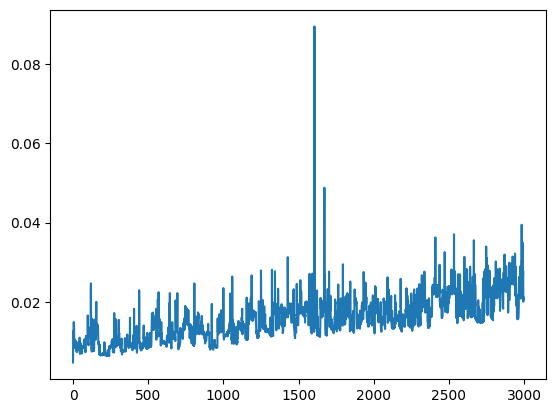

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

ypoints = np.array(list(token2latency.values()))
xpoints = np.array(list(range(0,3000)))

plt.plot(xpoints, ypoints)
plt.show()

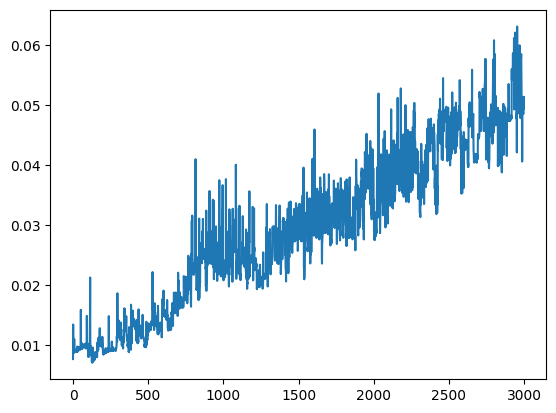

In [11]:
import matplotlib.pyplot as plt
import numpy as np

ypoints = np.array(list(token2latency_kv.values()))
xpoints = np.array(list(range(0,3000)))

plt.plot(xpoints, ypoints)
plt.show()

In [33]:
len(token2latency_kv.values())

2999

In [32]:
len(token2latency.values())

2999

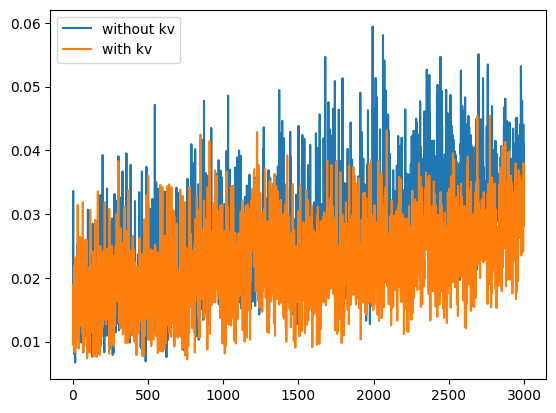

In [ ]:
import matplotlib.pyplot as plt

# Data
x = list(range(1,3000))
y1 = list(token2latency.values())
y2 = list(token2latency_kv.values())

# Plot both lines
plt.plot(x, y1, label='without kv')
plt.plot(x, y2, label='with kv')

# Add legend and show
plt.legend()
plt.show()

(2,0.035) (3000,060)

y = 0.025/2998 * x + 0.035

In [8]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 96.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 139.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 61.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [15]:
response = requests.post(url, json=data)
print_highlight(response.json())

{'detail': 'Method Not Allowed'}


In [ ]:
# sending a request to the sglang server and getting response

import requests

url = f"http://localhost:{port}/v1/chat/completions"

data = {
    "model": "qwen/qwen2.5-0.5b-instruct",
    "messages": [{"role": "user", "content": "What does the fox say"}], 
    # "text": "What does the fox say", 

    "max_tokens": 1
}

response = requests.post(url, json=data)
print_highlight(response.json())


{'id': '1221412130d743aeaa265cd7e15685bf', 'object': 'chat.completion', 'created': 1775684477, 'model': 'qwen/qwen2.5-0.5b-instruct', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': 'As', 'reasoning_content': None, 'tool_calls': None}, 'logprobs': None, 'finish_reason': 'length', 'matched_stop': None}], 'usage': {'prompt_tokens': 34, 'total_tokens': 35, 'completion_tokens': 1, 'prompt_tokens_details': None, 'reasoning_tokens': 0}, 'metadata': {'weight_version': 'default'}}


In [ ]:
url = f"http://127.0.0.1:{port}/debug/get_radix_tree"
# params = {"max_nodes": 1000, "include_values": False}

response = requests.get(url)

In [10]:
# helper functions to parse and build radix tree in a understandable format

import json
from copy import deepcopy


def parse_radix_response(response_text):
    """
    Convert response.text -> Python object.
    """
    return json.loads(response_text)


def build_radix_tree(radix_payload):
    if isinstance(radix_payload, dict):
        entries = [radix_payload]
    else:
        entries = radix_payload

    trees = []

    for entry in entries:
        nodes = deepcopy(entry["nodes"])

        for node in nodes:
            node["children"] = []

        nodes_sorted = sorted(nodes, key=lambda n: (n["prefix_length"], n["node_id"]))

        root = None
        for node in nodes_sorted:
            if node["is_root"]:
                root = node
                continue

            node_prefix = node["prefix_token_ids"]
            parent = None
            parent_len = -1

            for candidate in nodes_sorted:
                if candidate["node_id"] == node["node_id"]:
                    continue

                cand_prefix = candidate["prefix_token_ids"]

                if len(cand_prefix) >= len(node_prefix):
                    continue

                if node_prefix[: len(cand_prefix)] == cand_prefix:
                    if len(cand_prefix) > parent_len:
                        parent = candidate
                        parent_len = len(cand_prefix)

            if parent is None:
                raise ValueError(f"Could not find parent for node_id={node['node_id']}")

            parent["children"].append(node)

        if root is None:
            raise ValueError("No root node found")

        trees.append(
            {
                "dp_rank": entry.get("dp_rank"),
                "tp_rank": entry.get("tp_rank"),
                "pp_rank": entry.get("pp_rank"),
                "cache_type": entry.get("cache_type"),
                "root": root,
            }
        )

    return trees


def render_radix_tree_text(node, tokenizer=None, indent="", is_last=True):
    branch = "└── " if is_last else "├── "

    seg = node.get("segment_token_ids", [])
    prefix_len = node.get("prefix_length", 0)
    hit_count = node.get("hit_count", 0)
    kv_len = node.get("kv_indices_len", 0)
    node_id = node.get("node_id")

    decoded = None
    if tokenizer is not None and seg:
        try:
            decoded = tokenizer.decode(seg, skip_special_tokens=False).replace("\n", "\\n")
        except Exception:
            decoded = "<decode_failed>"

    line = (
        f"{indent}{branch}"
        f"id={node_id} "
        f"prefix_len={prefix_len} "
        f"seg_len={len(seg)} "
        f"kv_len={kv_len} "
        f"hits={hit_count} "
        f"tokens={seg}"
    )

    if decoded is not None:
        line += f' text="{decoded}"'

    lines = [line]

    children = node.get("children", [])
    next_indent = indent + ("    " if is_last else "│   ")

    for i, child in enumerate(children):
        lines.extend(
            render_radix_tree_text(
                child,
                tokenizer=tokenizer,
                indent=next_indent,
                is_last=(i == len(children) - 1),
            )
        )

    return lines


def print_radix_tree_from_response_text(response_json, tokenizer=None):
    trees = build_radix_tree(response_json)

    for i, tree in enumerate(trees):
        print(
            f"Tree {i} "
            f"(dp_rank={tree['dp_rank']}, tp_rank={tree['tp_rank']}, pp_rank={tree['pp_rank']}, cache_type={tree['cache_type']})"
        )
        print("\n".join(render_radix_tree_text(tree["root"], tokenizer=tokenizer)))
        print()


In [11]:
# more helper functions

def longest_prefix_in_radix_tree(text, tree_root, tokenizer):
    """
    Find the longest prefix of `text` already present in the radix tree.

    Returns a dict with:
    - matched_token_ids
    - matched_text
    - matched_length
    - last_node
    """
    input_token_ids = tokenizer.encode(text, add_special_tokens=False)

    node = tree_root
    matched = []

    while True:
        best_child = None
        best_match_len = 0

        for child in node.get("children", []):
            seg = child["segment_token_ids"]

            max_cmp = min(len(seg), len(input_token_ids) - len(matched))
            cur_match_len = 0

            while (
                cur_match_len < max_cmp
                and seg[cur_match_len] == input_token_ids[len(matched) + cur_match_len]
            ):
                cur_match_len += 1

            # In a radix tree, we only descend on full segment match
            if cur_match_len == len(seg) and cur_match_len > best_match_len:
                best_child = child
                best_match_len = cur_match_len

        if best_child is None:
            break

        matched.extend(best_child["segment_token_ids"])
        node = best_child

    return {
        "input_token_ids": input_token_ids,
        "matched_token_ids": matched,
        "matched_text": tokenizer.decode(matched, skip_special_tokens=False),
        "matched_length": len(matched),
        "last_node": node,
    }



def longest_prefix_token_ids(token_ids, tree_root):
    """
    Find the longest exact token-prefix already present in the radix tree.

    Returns:
    - matched_token_ids: longest prefix found in tree
    - matched_length: length of that prefix
    - matched_nodes: list of nodes traversed, excluding root
    - last_node: deepest matched node
    - unmatched_token_ids: remaining suffix
    """
    node = tree_root
    matched = []
    matched_nodes = []

    while True:
        best_child = None
        best_match_len = 0

        for child in node.get("children", []):
            seg = child["segment_token_ids"]
            start = len(matched)
            max_cmp = min(len(seg), len(token_ids) - start)

            cur_match_len = 0
            while (
                cur_match_len < max_cmp
                and seg[cur_match_len] == token_ids[start + cur_match_len]
            ):
                cur_match_len += 1

            # Radix-tree descent only on full segment match
            if cur_match_len == len(seg) and cur_match_len > best_match_len:
                best_child = child
                best_match_len = cur_match_len

        if best_child is None:
            break

        matched.extend(best_child["segment_token_ids"])
        matched_nodes.append(best_child)
        node = best_child

    return {
        "matched_token_ids": matched,
        "matched_length": len(matched),
        "matched_nodes": matched_nodes,
        "last_node": node,
        "unmatched_token_ids": token_ids[len(matched):],
    }


def longest_prefix_text(text, tree_root, tokenizer):
    """
    Same as longest_prefix_token_ids, but starts from raw text and adds decoded strings.
    """
    token_ids = tokenizer.encode(text, add_special_tokens=False)
    result = longest_prefix_token_ids(token_ids, tree_root)

    result["input_text"] = text
    result["input_token_ids"] = token_ids
    result["matched_text"] = tokenizer.decode(
        result["matched_token_ids"],
        skip_special_tokens=False,
    )
    result["unmatched_text"] = tokenizer.decode(
        result["unmatched_token_ids"],
        skip_special_tokens=False,
    )
    result["matched_node_path"] = [
        {
            "node_id": n["node_id"],
            "segment_token_ids": n["segment_token_ids"],
            "prefix_token_ids": n["prefix_token_ids"],
            "hit_count": n.get("hit_count"),
            "kv_indices_len": n.get("kv_indices_len"),
        }
        for n in result["matched_nodes"]
    ]
    return result


In [12]:
# initializing tokenizer of the LLM being used under the hood so as to calculate the prefix overlap with a RadixTree

from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "Qwen/Qwen2.5-0.5B-Instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)

/home/ssn899/miniforge3/envs/dist2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [14]:
# getting radix tree, building it in a understandable format, and gettig max prefix length for a particular request

url = f"http://127.0.0.1:{port}/debug/get_radix_tree"
# params = {"max_nodes": 1000, "include_values": False}

response = requests.get(url)

trees = build_radix_tree(response.json())
root = trees[0]["root"]

result = longest_prefix_text(
    "What does the fox say when it runs around like a maniac you little gay child",
    root,
    tokenizer,
)

print("matched_length:", result["matched_length"])
print("matched_text:", repr(result["matched_text"]))
print("unmatched_text:", repr(result["unmatched_text"]))
print("last_node_id:", result["last_node"]["node_id"])
print("path:", [n["node_id"] for n in result["matched_nodes"]])


matched_length: 13
matched_text: 'What does the fox say when it runs around like a maniac'
unmatched_text: ' you little gay child'
last_node_id: 18
path: [16, 6, 20, 18]


In [8]:
url = f"http://127.0.0.1:{port}/debug/get_radix_tree"
# params = {"max_nodes": 1000, "include_values": False}

response = requests.get(url)

print_radix_tree_from_response_text(response.json(),tokenizer=tokenizer)

Tree 0 (dp_rank=None, tp_rank=0, pp_rank=0, cache_type=RadixCache)
└── id=0 prefix_len=0 seg_len=0 kv_len=0 hits=0 tokens=[]
    └── id=2 prefix_len=6 seg_len=6 kv_len=6 hits=2 tokens=[785, 6722, 3283, 315, 9625, 374] text="The capital city of France is"
        └── id=3 prefix_len=14 seg_len=8 kv_len=8 hits=1 tokens=[12095, 13, 1084, 374, 279, 7772, 3283, 304] text=" Paris. It is the largest city in"

